#### Case 1: Isobaric evaporation of liquid hydrogen in a 4.89 $m^3$ spherical tank experiments.

This notebook compares the isobaric evaporation of liquid hydrogen ($LH_2$) in a 4.89 $m^3$ spherical storage tank to the isobaric evaporation of liquid hydrogen ($LH_2$) in a 4.89 $m^3$ cylindrical storage tank. The tank parameters from Hasan (1991) are considered.

In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

from scipy.integrate import simps, trapezoid

from mpltools import annotation

#### Setup tank and cryogen properties

In [2]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
d_i = 2.106 # Internal diameter / m
d_o = 2.106+2.08e-3   # External diameter / m
T_air = 350 # Temperature of the environment K

# Set overall heat transfer coefficient through the walls for liquid and vapour
#df_evap["SCHM BOG"] = ((df_evap["BOG"]*1000*3600/2)*(273+15)*8.314)/101325 #flux = uT  BOG kg = heat/specific enthalpy flux = BOG*specific enthalpy/area

U_L = 0.01176 # W/m2/K up to 0.1-0.2
U_V = 0.05575 # W/m2/K

# Specify heat transfer rate at the bottom to prevent ground heating
Q_b = 0 # W, 

# Spherical tank volume
V_tank = 4.89 #m^3

# Initial liquid filling / Dimensionless
LF = 0.5

# Specify tank operating pressure
P = 117e3 # Pa

Geo_v1 = "spherical"
Geo_l1 = "spherical"

Geo_v2 = "cylindrical"
Geo_l2 = "cylindrical"

# Initialize large-scale tank
small_tank1 = Tank(d_i, d_o, V_tank, Geo_v1, Geo_l1,LF)
small_tank1.set_HeatTransProps(U_L, U_V, T_air, Q_b, Q_roof, eta_w = 0)

small_tank2 = Tank(d_i, d_o, V_tank, Geo_v2, Geo_l2,LF)
small_tank2.set_HeatTransProps(U_L, U_V, T_air, Q_b_fixed=None, Q_roof=Q_roof, eta_w = 0)

# Initialise cryogen
hydrogen1 = Cryogen(name = "hydrogen")
hydrogen1.set_coolprops(P)

hydrogen2 = Cryogen(name='hydrogen')
hydrogen2.set_coolprops(P)

# Set cryogen
small_tank1.cryogen = hydrogen1
small_tank2.cryogen = hydrogen2

# Calculate initial evaporation rate
print("The initial evaporation rate of " + hydrogen1.name + " is %.1e kg/h" % (small_tank1.b_l_dot * 3600))
print("The initial evaporation rate of " + hydrogen2.name + " is %.1e kg/h" % (small_tank2.b_l_dot * 3600))

The initial evaporation rate of hydrogen is 2.2e-01 kg/h
The initial evaporation rate of hydrogen is 2.5e-01 kg/h


Calculate initial evaporation rate and transient period

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + hydrogen1.name + " is %.1e kg/h" % (small_tank1.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % small_tank1.tau)

# Minimum number of hours to achieve steady state 
tau_h1 = (np.floor(small_tank1.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h1 )

# Calculate boil-off rate
BOR1 = (small_tank1.b_l_dot * 24 * 3600) / (small_tank1.V * small_tank1.LF * small_tank1.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR1 * 100))
print('Area = ',small_tank1.A_T)
print("vz at t=0 = ",small_tank1.v_z,'\n')

# Calculate initial evaporation rate
print("The initial evaporation rate of " + hydrogen2.name + " is %.1e kg/h" % (small_tank2.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % small_tank2.tau)

# Minimum number of hours to achieve steady state 
tau_h2 = (np.floor(small_tank2.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h2 )

# Calculate boil-off rate
BOR2 = (small_tank2.b_l_dot * 24 * 3600) / (small_tank2.V * small_tank2.LF * small_tank2.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR2 * 100))
print('Area = ',small_tank2.A_T)
print("vz at t=0 = ",small_tank2.v_z)

The initial evaporation rate of hydrogen is 2.2e-01 kg/h
Transient period = 91936.900 s 
Simulation time: 26 h
BOR = 3.044 %
Area =  3.483426174104408
vz at t=0 =  1.1454648100592547e-05 

The initial evaporation rate of hydrogen is 2.5e-01 kg/h
Transient period = 52595.671 s 
Simulation time: 15 h
BOR = 3.547 %
Area =  3.4834262086342447
vz at t=0 =  1.334511281014727e-05


#### Simulation setup and execution

In [4]:
# Define vertical spacing
dz = 0.025

# Calculate number of nodes
n_z = 1 + int(np.round(small_tank1.l_V/dz, 0))

print(n_z)

dz2=0.015

n_z2 = 1 + int(np.round(small_tank2.l_V/dz2, 0))

print(n_z2)

# Define dimensionless computational grid
small_tank1.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
small_tank1.U_roof = 0

# Define evaporation time as twice as the transient period
evap_time = 24*3600*6
#evap_time = 3600*24*2

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
small_tank1.time_interval = 30

# Time step to plot each vapour temperature profile
small_tank1.plot_interval = evap_time/6

# Simulate the evaporation
small_tank1.evaporate(evap_time)

# Calculate number of nodes


# Define dimensionless computational grid
small_tank2.z_grid = np.linspace(0, 1, n_z2)

# Insulated roof
small_tank2.U_roof = 0

# Define evaporation time as twice as the transient period
evap_time = 3600 *24*6
#evap_time = 3600*24*2

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
small_tank2.time_interval = 30

# Time step to plot each vapour temperature profile
small_tank2.plot_interval = evap_time/6

# Simulate the evaporation
small_tank2.evaporate(evap_time)

43
48


/home/aeb23/IRP/CryoEvap/notebooks/../cryoevap/storage_tanks/tank.py:472: RuntimeWarning: divide by zero encountered in divide
  vz = self.v_z*(l_L[i]/zed)*(2*self.d_i/2 - l_L[i])/(2*self.d_i/2 - zed)


#### Visualisation of results

#### Vapour temperature

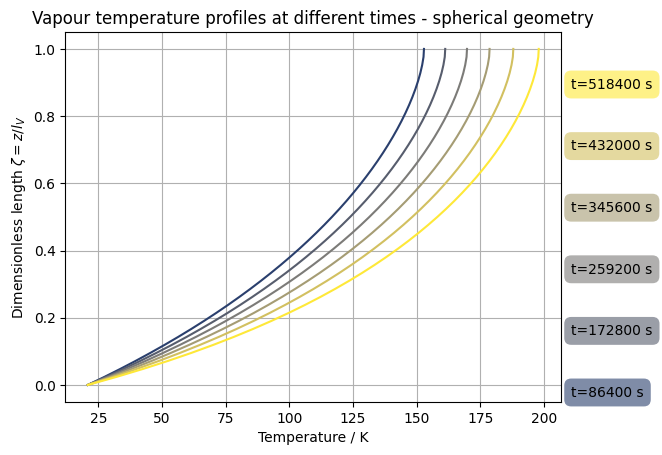

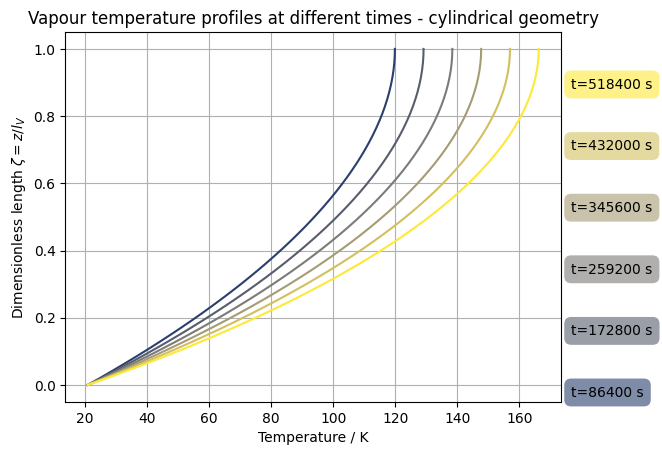

In [5]:
# Visualise the plot
small_tank1.plot_tv()
#plt.ylim((0,0.3))
#plt.xlim((20.86,21))
small_tank2.plot_tv()
#plt.xlim((20.86,21))

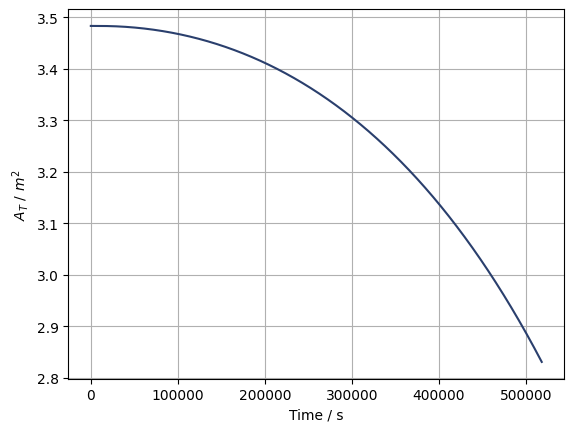

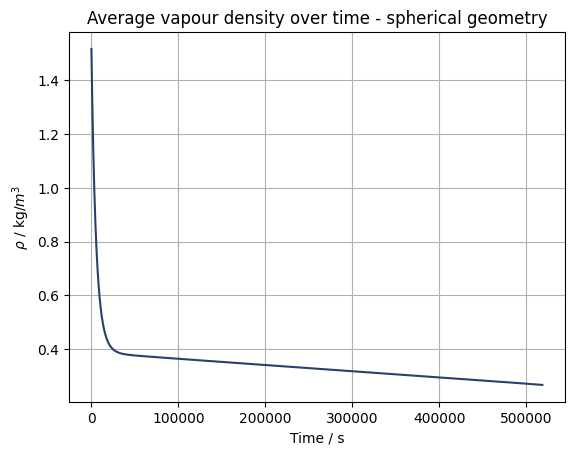

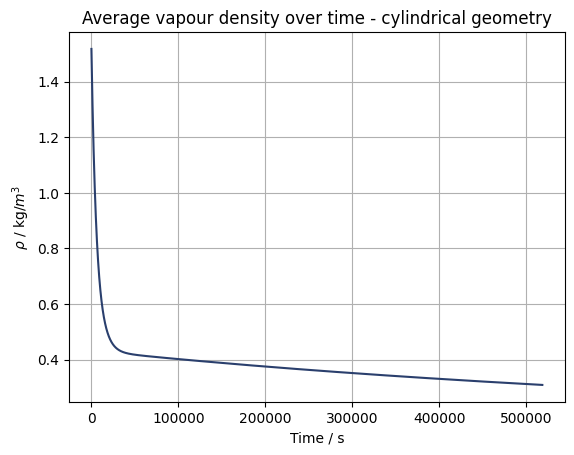

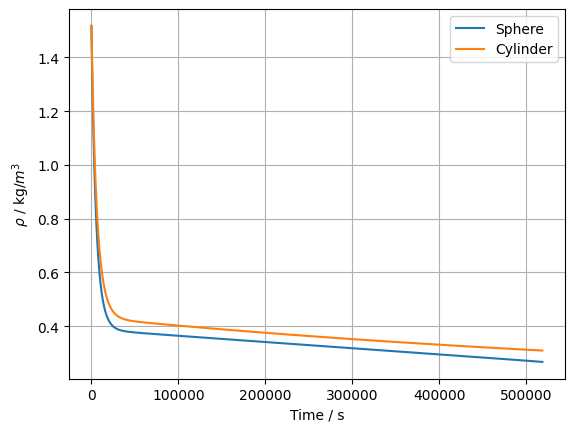

In [6]:
small_tank1.plot_A_T()
small_tank1.plot_rho_V_avg()
small_tank2.plot_rho_V_avg()
plt.plot(small_tank1.data['Time'],small_tank1.data['rho_V_avg'],small_tank2.data['Time'],small_tank2.data['rho_V_avg'])
plt.legend(['Sphere','Cylinder'])
plt.xlabel('Time / s')
plt.ylabel(r'$\rho$ / kg/$m^3$')
plt.grid(True)

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

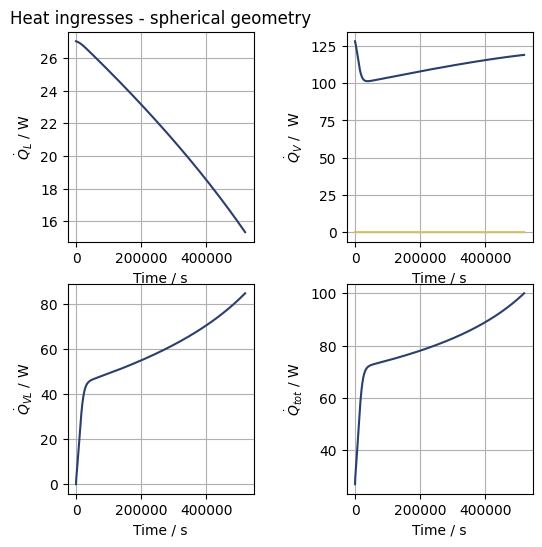

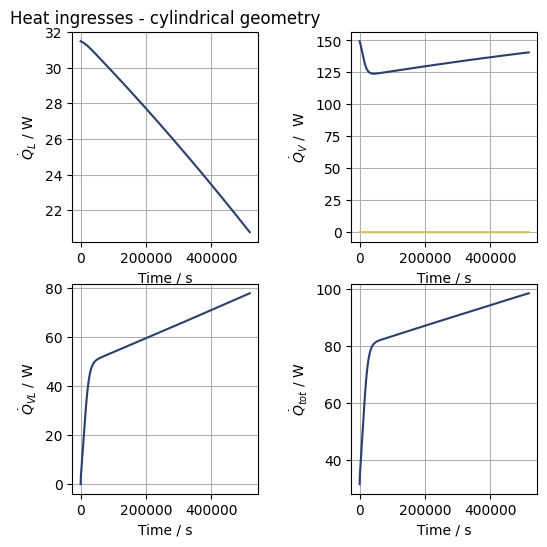

In [7]:
# Provide optional parameter unit to
# accommodate the scale of the experiment
small_tank1.plot_Q(unit="W")
small_tank2.plot_Q(unit='W')

#### Plot liquid volume

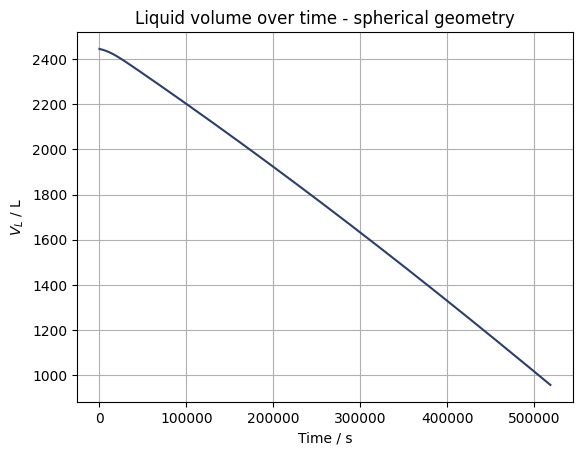

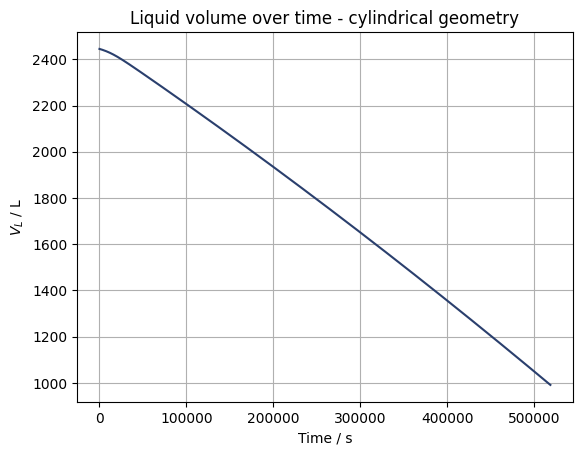

Text(0, 0.5, '$V_L$ / $m^3$')

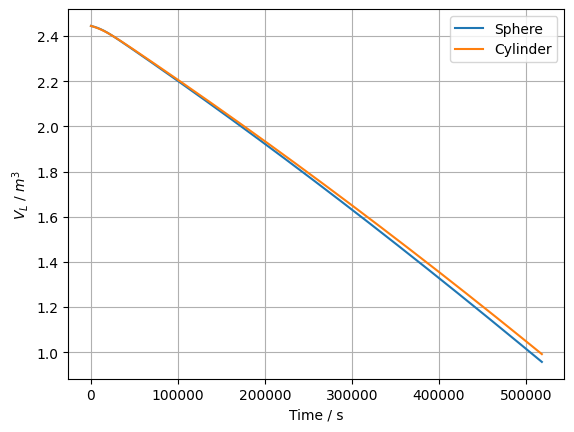

In [8]:
# Provide optional parameter unit to
# accommodate the scale of the experiment
small_tank1.plot_V_L(unit="L")
small_tank2.plot_V_L(unit='L')
plt.plot(small_tank1.data['Time'],small_tank1.data['V_L'],small_tank2.data['Time'],small_tank2.data['V_L'])
plt.grid(True)
plt.legend(['Sphere','Cylinder'])
plt.xlabel('Time / s')
plt.ylabel('$V_L$ / $m^3$')

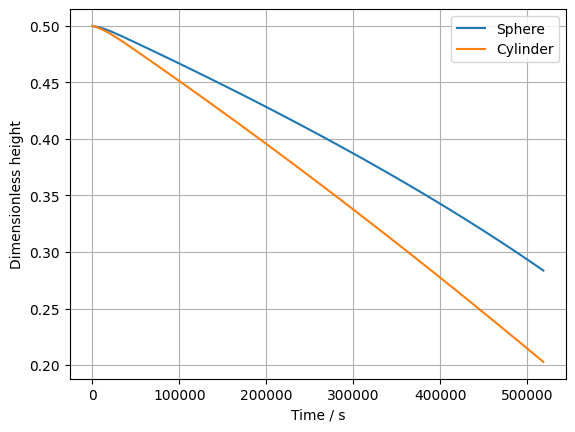

In [9]:
plt.plot(small_tank1.data['Time'],small_tank1.data['z']/d_i,small_tank2.data['Time'],small_tank2.data['z']*np.pi*d_i**2 / (4 * V_tank))
plt.grid(True)
plt.xlabel('Time / s')
plt.ylabel('Dimensionless height')
plt.legend(['Sphere','Cylinder'])

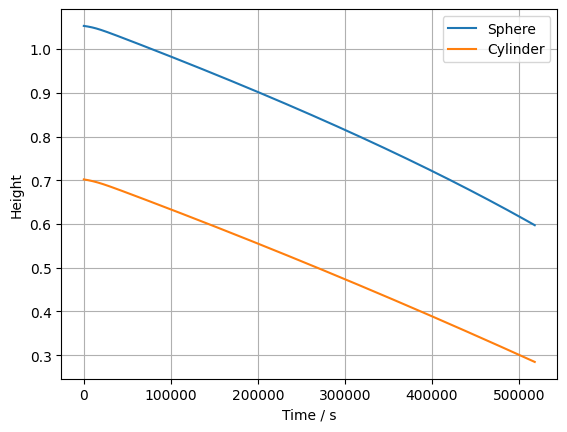

In [10]:
plt.plot(small_tank1.data['Time'],small_tank1.data['z'],small_tank2.data['Time'],small_tank2.data['z'])
plt.grid(True)
plt.xlabel('Time / s')
plt.ylabel('Height')
plt.legend(['Sphere','Cylinder'])

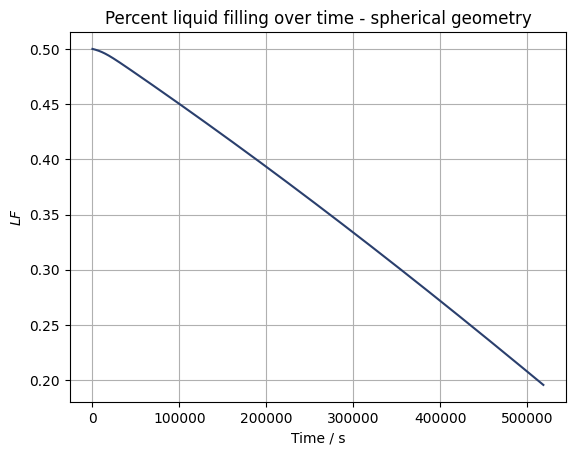

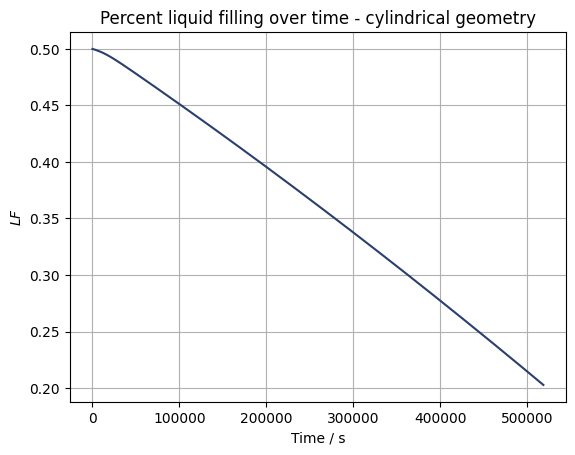

Text(0, 0.5, 'LF')

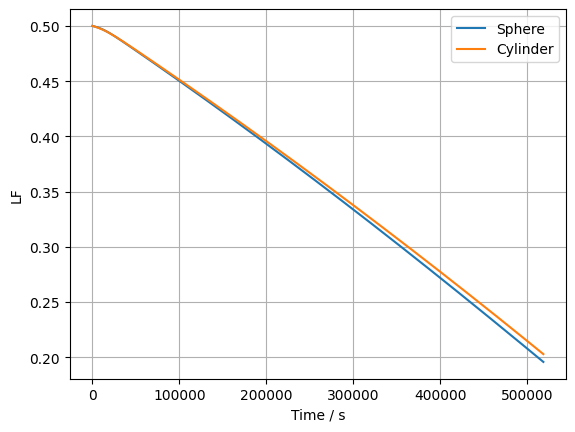

In [11]:
small_tank1.plot_LF()
small_tank2.plot_LF()
plt.plot(small_tank1.data['Time'],small_tank1.data['LF'],small_tank2.data['Time'],small_tank2.data['LF'])
plt.legend(['Sphere','Cylinder'])
plt.grid(True)
plt.xlabel('Time / s')
plt.ylabel('LF')
#plt.ylim((0,1))

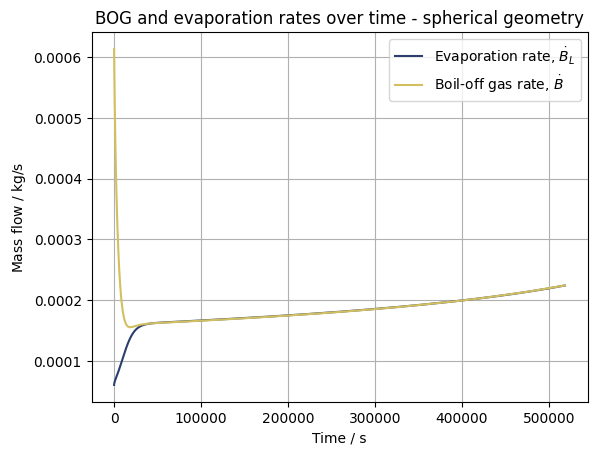

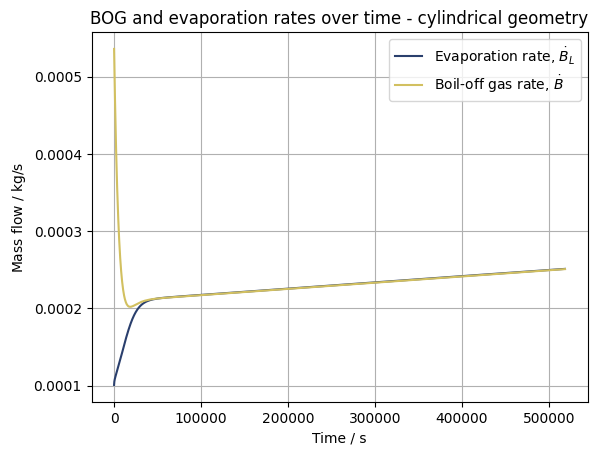

In [12]:
# Provide optional parameter unit to
# accommodate the scale of the experiment
small_tank1.plot_BOG(unit='kg/s')
small_tank2.plot_BOG(unit='kg/s')

/home/aeb23/IRP/CryoEvap/notebooks/../cryoevap/storage_tanks/plots.py:265: RuntimeWarning: divide by zero encountered in divide
  v_z = tank.v_z*(height/zed)*(2*tank.d_i/2 - height)/(2*tank.d_i/2 - zed)


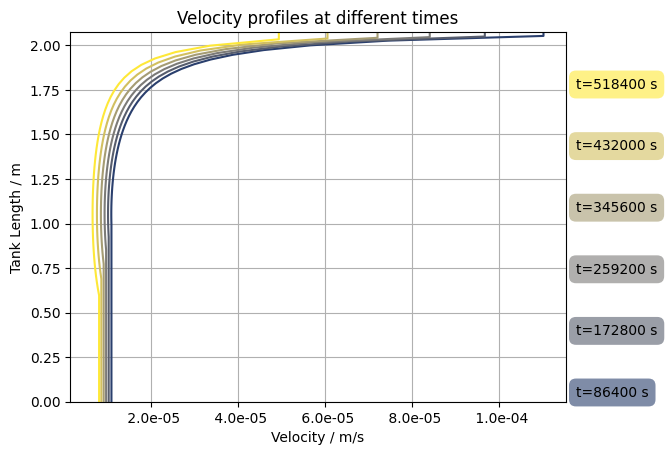

In [13]:
small_tank1.plot_vz()

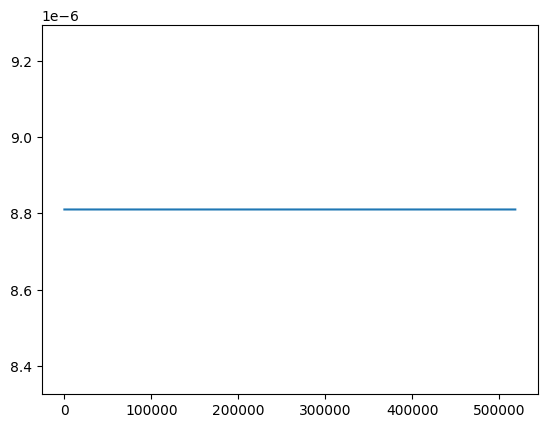

In [14]:
plt.plot(small_tank2.data['Time'],small_tank2.data['vz'])

In [15]:
small_tank1.data["Pressure"] = np.ones_like(small_tank1.data["B_L"])*P
air = P*(V_tank*(1-LF))/(8.314*hydrogen1.T_sat)
for i in range(1,len(small_tank1.data["B_L"])):
    small_tank1.data["Pressure"][i] = ((simps(small_tank1.data["B_L"][:i])*(1000/2) +air)*8.314*small_tank1.data["Tv_avg"][i])/(V_tank - small_tank1.data["V_L"][i])

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [16]:
# Import pandas 
import pandas as pd

In [17]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(small_tank1.data)
df_evap2 = pd.DataFrame.from_dict(small_tank2.data)
# Save file to the current working directory
df_evap.to_csv('LN2_small_m3.csv')

In [18]:
df_evap['flux_v'] = df_evap["Q_V"]/(np.pi*d_i*(d_i-df_evap['z']))
df_evap['flux_l'] = df_evap["Q_L"]/(np.pi*d_i*(df_evap['z']))
df_evap['total_flux'] = (df_evap['Q_L']+df_evap['Q_V'])/(np.pi*d_i**2)

In [19]:
df_evap.head()

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,...,A_T,vz_avg,vz,LF,dTV_avg,Q_Vw,Pressure,flux_v,flux_l,total_flux
0,0,20.866191,1.517212,-3.626545e-15,27.016599,128.101618,2.445000,0.000061,0.000061,0.000000,...,3.483426,0.000018,0.000011,0.500000,0.000000,0.0,117000.000000,18.385471,3.878263,11.132590
1,30,20.937724,1.510417,1.666024e-01,27.016408,128.074682,2.444974,0.000061,0.000613,-0.000226,...,3.483426,0.000018,0.000011,0.499995,0.002386,0.0,117399.847846,18.381475,3.878263,11.130643
2,60,21.009333,1.503622,3.226729e-01,27.016216,128.047720,2.444948,0.000061,0.000611,-0.000225,...,3.483426,0.000018,0.000011,0.499989,0.002389,0.0,117802.281195,18.377475,3.878263,11.128694
3,90,21.081046,1.496902,4.692788e-01,27.016025,128.020712,2.444922,0.000062,0.000605,-0.000223,...,3.483426,0.000018,0.000011,0.499984,0.002393,0.0,118205.323532,18.373469,3.878263,11.126742
4,120,21.152887,1.490252,6.073891e-01,27.015831,127.993670,2.444896,0.000062,0.000600,-0.000221,...,3.483426,0.000018,0.000011,0.499979,0.002397,0.0,118609.077082,18.369456,3.878264,11.124787


In [20]:
df_evap["SCHM BOG"] = ((df_evap["BOG"]*1000*3600/2)*(273+15)*8.314)/101325
df_evap2["SCHM BOG"] = ((df_evap2["BOG"]*1000*3600/2)*(273+15)*8.314)/101325
df_evap[-5:]

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,...,vz_avg,vz,LF,dTV_avg,Q_Vw,Pressure,flux_v,flux_l,total_flux,SCHM BOG
17276,518280,136.588908,0.267123,84.683716,15.339845,118.953912,0.957285,0.000224,0.000224,-2.501431e-07,...,0.000009,0.000008,0.195764,0.000116,0.0,929754.435741,11.917629,3.881182,9.638051,9.539879
17277,518310,136.592394,0.267115,84.688158,15.338978,118.954632,0.957189,0.000224,0.000224,-2.499754e-07,...,0.000009,0.000008,0.195744,0.000116,0.0,929787.902972,11.917434,3.881182,9.638040,9.540194
17278,518340,136.595865,0.267108,84.692592,15.338112,118.955360,0.957094,0.000224,0.000224,-2.499225e-07,...,0.000009,0.000008,0.195725,0.000116,0.0,929821.266975,11.917240,3.881182,9.638030,9.540527
17279,518370,136.599347,0.267100,84.697033,15.337245,118.956083,0.956998,0.000224,0.000224,-2.500641e-07,...,0.000009,0.000008,0.195705,0.000116,0.0,929854.706159,11.917046,3.881183,9.638020,9.540893
17280,518400,136.602829,0.267093,84.701474,15.336379,118.956805,0.956902,0.000224,0.000224,-2.500747e-07,...,0.000009,0.000008,0.195686,0.000116,0.0,929888.148816,11.916851,3.881183,9.638010,9.541237


In [21]:
df_evap['Q_tot']=df_evap['Q_L']+df_evap['Q_Vw']+df_evap['Q_VL']/(4*np.pi*(d_i/2)**2)

In [22]:
((4.7-df_evap.loc[df_evap['Time']==21*3600,'SCHM BOG'])/4.7)*100

2520   -48.786219
Name: SCHM BOG, dtype: float64

In [23]:
df_evap2.columns

Index(['Time', 'Tv_avg', 'rho_V_avg', 'Q_VL', 'Q_L', 'Q_V', 'V_L', 'B_L',
       'BOG', 'drho_V_avg', 'dV_L', 'z', 'vz', 'LF', 'dTV_avg', 'Q_Vw',
       'SCHM BOG'],
      dtype='object')

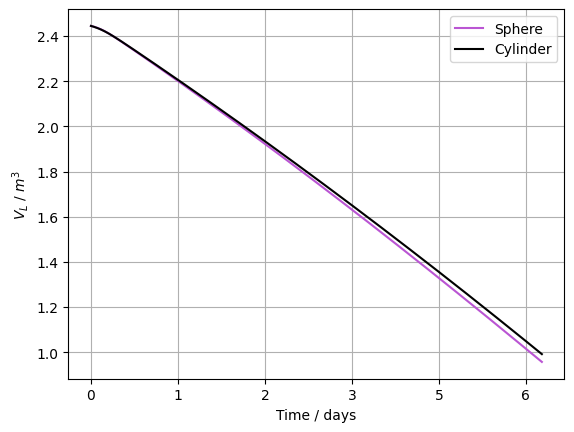

In [24]:
plt.plot(df_evap['Time'],df_evap['V_L'],color='mediumorchid')
plt.plot(df_evap2['Time'],df_evap2['V_L'],'k')
plt.grid(True)
xloc = plt.xticks()[0]
plt.xticks([round(i,1) for i in xloc[1:-1]],[round(i/(3600*24)) for i in xloc[1:-1]])
plt.xlabel('Time / days')
plt.ylabel('$V_{L}$ / $m^{3}$')
plt.legend(['Sphere','Cylinder'])

Text(0, 0.5, 'Mass Flow / kg/s')

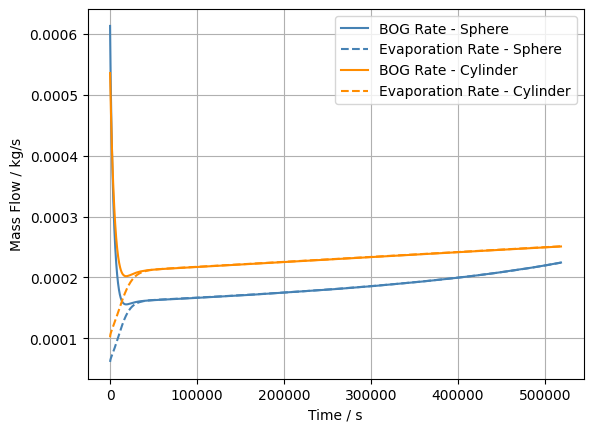

In [25]:
plt.plot(df_evap['Time'][1:],df_evap['BOG'][1:],'-',color='steelblue')
plt.plot(df_evap['Time'][1:],df_evap['B_L'][1:],'--',color='steelblue')
plt.plot(df_evap2['Time'][1:],df_evap2['BOG'][1:],'darkorange')
plt.plot(df_evap2['Time'][1:],df_evap2['B_L'][1:],'--',color='darkorange')
plt.legend(['BOG Rate - Sphere','Evaporation Rate - Sphere','BOG Rate - Cylinder','Evaporation Rate - Cylinder'])
yloc = plt.yticks()[0]
xloc = plt.xticks()[0]
plt.xticks([round(i,1) for i in xloc[1:-1]],[round(i) for i in xloc[1:-1]])
plt.yticks([i for i in yloc[1:-1]],[round(i,5) for i in yloc[1:-1]])
plt.grid(True)
plt.xlabel('Time / s')
plt.ylabel('Mass Flow / kg/s')

In [26]:
df_evap2['B_L']*hydrogen2.rho_L

0        0.007080
1        0.007131
2        0.007174
3        0.007210
4        0.007242
           ...   
17276    0.017639
17277    0.017639
17278    0.017640
17279    0.017640
17280    0.017640
Name: B_L, Length: 17281, dtype: float64

Text(0, 0.5, 'Volume flow / m^3/s')

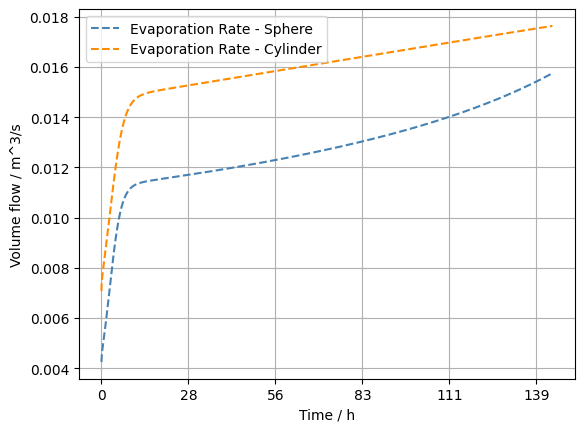

In [27]:
plt.plot(df_evap['Time'],df_evap['B_L']*hydrogen1.rho_L,'--',color='steelblue')
plt.plot(df_evap2['Time'],df_evap2['B_L']*hydrogen2.rho_L,'--',color='darkorange')
plt.legend(['Evaporation Rate - Sphere','Evaporation Rate - Cylinder'])
#yloc = plt.yticks()[0]
#xloc = plt.xticks()[0]
plt.xticks([round(i,1) for i in xloc[1:-1]],[round(i/3600) for i in xloc[1:-1]])
#plt.yticks([i for i in yloc[1:-1]],[round(i,5) for i in yloc[1:-1]])
plt.grid(True)
plt.xlabel('Time / h')
plt.ylabel('Volume flow / m^3/s')

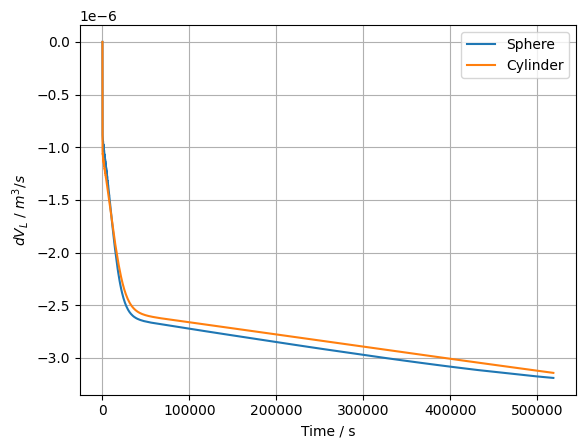

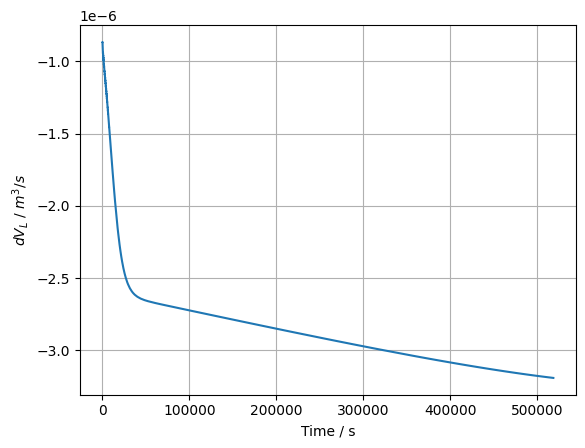

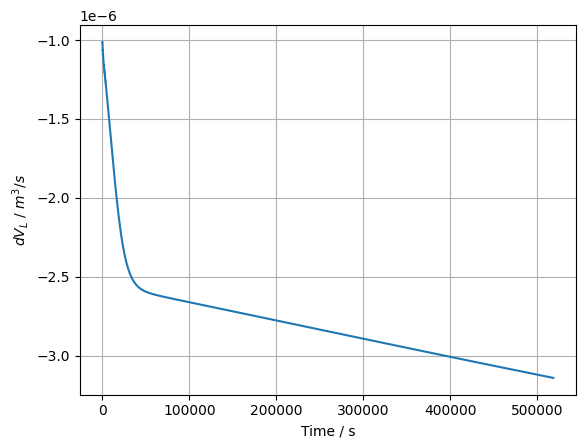

In [28]:
plt.plot(df_evap['Time'],df_evap['dV_L'],df_evap2['Time'],df_evap2['dV_L'])
plt.legend(['Sphere','Cylinder'])
plt.grid(True)
plt.xlabel('Time / s')
plt.ylabel('$dV_L$ / $m^3/s$')
plt.figure()
plt.plot(df_evap['Time'][1:],df_evap['dV_L'][1:])
plt.xlabel('Time / s')
plt.ylabel('$dV_L$ / $m^3/s$')
plt.grid(True)
plt.figure()
plt.plot(df_evap2['Time'][1:],df_evap2['dV_L'][1:])
plt.xlabel('Time / s')
plt.ylabel('$dV_L$ / $m^3/s$')
plt.grid(True)

In [29]:
assert(df_evap['Time']==df_evap2['Time']).all()

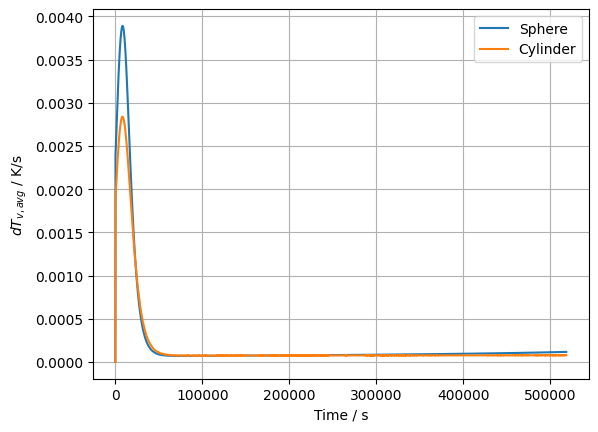

In [30]:
plt.plot(df_evap['Time'],df_evap['dTV_avg'])
plt.plot(df_evap2['Time'],df_evap2['dTV_avg'])
plt.grid(True)
plt.xlabel('Time / s')
plt.ylabel('$dT_{v, avg}$ / K/s')
plt.legend(['Sphere','Cylinder'])

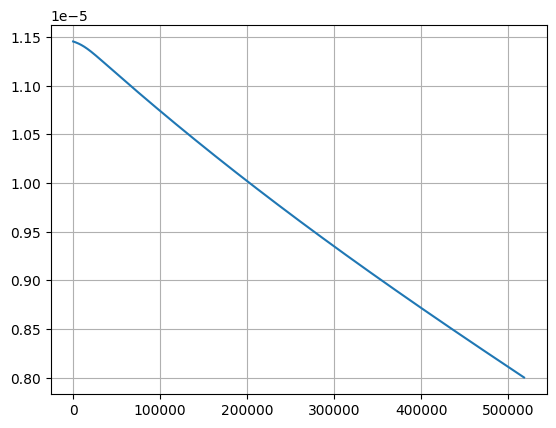

In [31]:
plt.plot(small_tank1.data['Time'],small_tank1.data['vz'])
plt.grid(True)

In [32]:
df_evap.head()

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,...,vz,LF,dTV_avg,Q_Vw,Pressure,flux_v,flux_l,total_flux,SCHM BOG,Q_tot
0,0,20.866191,1.517212,-3.626545e-15,27.016599,128.101618,2.445000,0.000061,0.000061,0.000000,...,0.000011,0.500000,0.000000,0.0,117000.000000,18.385471,3.878263,11.132590,2.575231,27.016599
1,30,20.937724,1.510417,1.666024e-01,27.016408,128.074682,2.444974,0.000061,0.000613,-0.000226,...,0.000011,0.499995,0.002386,0.0,117399.847846,18.381475,3.878263,11.130643,26.090807,27.028364
2,60,21.009333,1.503622,3.226729e-01,27.016216,128.047720,2.444948,0.000061,0.000611,-0.000225,...,0.000011,0.499989,0.002389,0.0,117802.281195,18.377475,3.878263,11.128694,25.976578,27.039373
3,90,21.081046,1.496902,4.692788e-01,27.016025,128.020712,2.444922,0.000062,0.000605,-0.000223,...,0.000011,0.499984,0.002393,0.0,118205.323532,18.373469,3.878263,11.126742,25.739870,27.049705
4,120,21.152887,1.490252,6.073891e-01,27.015831,127.993670,2.444896,0.000062,0.000600,-0.000221,...,0.000011,0.499979,0.002397,0.0,118609.077082,18.369456,3.878264,11.124787,25.517278,27.059422


In [33]:
df_evap2.head()

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,dV_L,z,vz,LF,dTV_avg,Q_Vw,SCHM BOG
0,0,20.866191,1.517253,-7.492516e-15,31.475394,149.340028,2.445000,0.000101,0.000101,0.000000,0.000000,0.701895,0.000009,0.500000,0.000000,0.0,4.285449
1,30,20.922129,1.511905,3.242093e-01,31.475171,149.315703,2.444970,0.000101,0.000536,-0.000178,-0.000001,0.701886,0.000009,0.499994,0.001866,0.0,22.793538
2,60,20.978151,1.506556,5.958339e-01,31.474947,149.291347,2.444939,0.000102,0.000535,-0.000178,-0.000001,0.701878,0.000009,0.499988,0.001869,0.0,22.756551
3,90,21.034281,1.501244,8.272114e-01,31.474724,149.266934,2.444909,0.000103,0.000533,-0.000177,-0.000001,0.701869,0.000009,0.499981,0.001873,0.0,22.656266
4,120,21.090543,1.495966,1.029535e+00,31.474496,149.242486,2.444878,0.000103,0.000530,-0.000175,-0.000001,0.701860,0.000009,0.499975,0.001878,0.0,22.559866


In [34]:
df_evap[-5:]

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,...,vz,LF,dTV_avg,Q_Vw,Pressure,flux_v,flux_l,total_flux,SCHM BOG,Q_tot
17276,518280,136.588908,0.267123,84.683716,15.339845,118.953912,0.957285,0.000224,0.000224,-2.501431e-07,...,0.000008,0.195764,0.000116,0.0,929754.435741,11.917629,3.881182,9.638051,9.539879,21.417461
17277,518310,136.592394,0.267115,84.688158,15.338978,118.954632,0.957189,0.000224,0.000224,-2.499754e-07,...,0.000008,0.195744,0.000116,0.0,929787.902972,11.917434,3.881182,9.638040,9.540194,21.416914
17278,518340,136.595865,0.267108,84.692592,15.338112,118.955360,0.957094,0.000224,0.000224,-2.499225e-07,...,0.000008,0.195725,0.000116,0.0,929821.266975,11.917240,3.881182,9.638030,9.540527,21.416365
17279,518370,136.599347,0.267100,84.697033,15.337245,118.956083,0.956998,0.000224,0.000224,-2.500641e-07,...,0.000008,0.195705,0.000116,0.0,929854.706159,11.917046,3.881183,9.638020,9.540893,21.415818
17280,518400,136.602829,0.267093,84.701474,15.336379,118.956805,0.956902,0.000224,0.000224,-2.500747e-07,...,0.000008,0.195686,0.000116,0.0,929888.148816,11.916851,3.881183,9.638010,9.541237,21.415270


In [35]:
df_evap['B_L'][-5:]

17276    0.000224
17277    0.000224
17278    0.000224
17279    0.000224
17280    0.000224
Name: B_L, dtype: float64

In [36]:
df_evap2[-5:]

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,dV_L,z,vz,LF,dTV_avg,Q_Vw,SCHM BOG
17276,518280,118.610804,0.309391,77.747530,20.781674,140.629664,0.991823,0.000251,0.000251,-1.707776e-07,-0.000003,0.284726,0.000009,0.202827,0.000076,0.0,10.664009
17277,518310,118.613092,0.309386,77.749195,20.780981,140.630585,0.991728,0.000251,0.000251,-1.724553e-07,-0.000003,0.284699,0.000009,0.202807,0.000077,0.0,10.664381
17278,518340,118.615407,0.309380,77.751155,20.780287,140.631490,0.991634,0.000251,0.000251,-1.719992e-07,-0.000003,0.284672,0.000009,0.202788,0.000077,0.0,10.664427
17279,518370,118.617685,0.309375,77.752713,20.779593,140.632418,0.991540,0.000251,0.000251,-1.712872e-07,-0.000003,0.284645,0.000009,0.202769,0.000076,0.0,10.664392
17280,518400,118.619984,0.309370,77.754507,20.778900,140.633332,0.991446,0.000251,0.000251,-1.732669e-07,-0.000003,0.284618,0.000009,0.202750,0.000077,0.0,10.664826


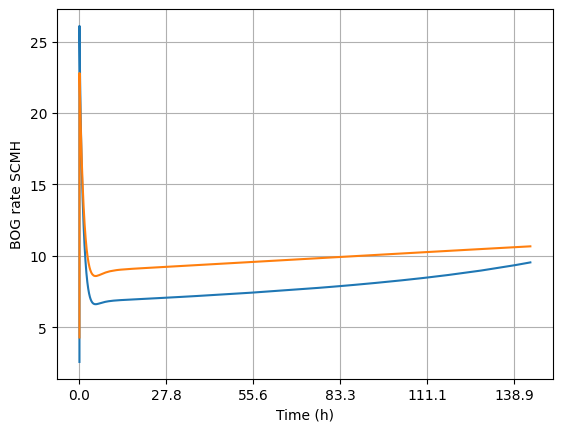

In [37]:
plt.plot(df_evap['Time'],df_evap['SCHM BOG'],df_evap2['Time'],df_evap2['SCHM BOG'])
plt.ylabel('BOG rate SCMH')
plt.xlabel('Time (h)')
loc = plt.xticks()[0]
plt.xticks([round(i) for i in loc[1:-1]],[round(i/3600,1) for i in loc[1:-1]])
plt.grid(True)

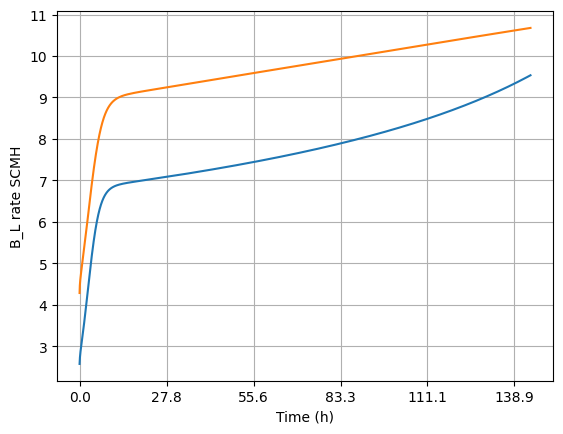

In [38]:
plt.plot(df_evap['Time'],((df_evap["B_L"]*1000*3600/2)*(273+15)*8.314)/101325,df_evap2['Time'],((df_evap2["B_L"]*1000*3600/2)*(273+15)*8.314)/101325)
plt.ylabel('B_L rate SCMH')
plt.xlabel('Time (h)')
loc = plt.xticks()[0]
plt.xticks([round(i) for i in loc[1:-1]],[round(i/3600,1) for i in loc[1:-1]])
plt.grid(True)

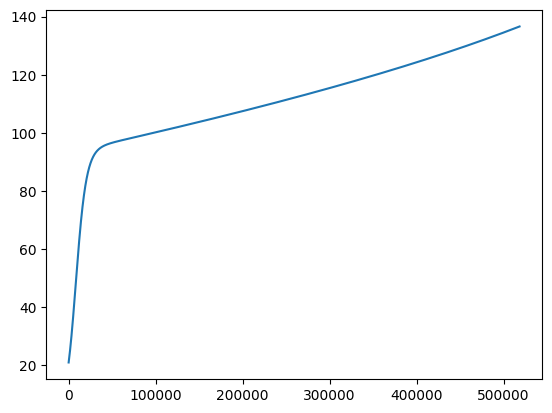

In [39]:
plt.plot(df_evap['Time'],df_evap['Tv_avg'])

In [40]:
df_evap[['z','A_T','V_L','LF']]

,z,A_T,V_L,LF
0,1.052895,3.483426,2.445000,0.500000
1,1.052888,3.483426,2.444974,0.499995
2,1.052880,3.483426,2.444948,0.499989
3,1.052873,3.483426,2.444922,0.499984
4,1.052865,3.483426,2.444896,0.499979
...,...,...,...,...
17276,0.597377,2.831257,0.957285,0.195764
17277,0.597344,2.831160,0.957189,0.195744
17278,0.597310,2.831063,0.957094,0.195725
17279,0.597276,2.830966,0.956998,0.195705


In [41]:
df_evap2[['z','V_L','LF']]

,z,V_L,LF
0,0.701895,2.445000,0.500000
1,0.701886,2.444970,0.499994
2,0.701878,2.444939,0.499988
3,0.701869,2.444909,0.499981
4,0.701860,2.444878,0.499975
...,...,...,...
17276,0.284726,0.991823,0.202827
17277,0.284699,0.991728,0.202807
17278,0.284672,0.991634,0.202788
17279,0.284645,0.991540,0.202769


In [42]:
len(df_evap['V_L'])//2
df_evap['B_L'][len(df_evap['V_L'])//2:]

8640     0.000181
8641     0.000181
8642     0.000181
8643     0.000181
8644     0.000181
           ...   
17276    0.000224
17277    0.000224
17278    0.000224
17279    0.000224
17280    0.000224
Name: B_L, Length: 8641, dtype: float64

In [44]:
guess_sphere=-simps(df_evap['B_L'],df_evap['Time'])/hydrogen1.rho_L
actual_sphere = -df_evap['V_L'][0]+df_evap['V_L'][len(df_evap['V_L'])-1]

guess_cylinder = -simps(df_evap2['B_L'],df_evap2['Time'])/hydrogen2.rho_L
actual_cylinder=-df_evap2['V_L'][0]+df_evap2['V_L'][len(df_evap2['V_L'])-1]

guess_s2=simps(df_evap['dV_L'],df_evap['Time'])
guess_c2=simps(df_evap2['dV_L'],df_evap2['Time'])


trap_s=-trapezoid(df_evap['B_L'],df_evap['Time'])/hydrogen1.rho_L
trap_c=-(trapezoid(df_evap2['B_L'],df_evap2['Time'])/hydrogen2.rho_L)

print('Simps error sphere: ',abs((guess_sphere-actual_sphere)/actual_sphere)*100)
print('Simps error cylinder: ',abs((guess_cylinder-actual_cylinder)/actual_cylinder)*100)
print('Trap error sphere: ',abs((trap_s-actual_sphere)/actual_sphere)*100)
print('Trap error cylinder: ',abs((trap_c-actual_cylinder)/actual_cylinder)*100)



Simps error sphere:  9.836226202058837
Simps error cylinder:  15.336279677411557
Trap error sphere:  9.836227101444784
Trap error cylinder:  15.336277422735245


#### References



Hasan, M., Lin, C. and Van Dresar, N. (1991). Self-Pressurization of a Flightweight Liquid Hydrogen Storage Tank Subjected to Low Heat Flux. [online] Available at: https://ntrs.nasa.gov/api/citations/19910011011/downloads/19910011011.pdf [Accessed 2 Jul. 2024].

Wang, Z. and Mérida, W. (2024). Thermal performance of cylindrical and spherical liquid hydrogen tanks. International Journal of Hydrogen Energy, 53, pp.667–683. doi:https://doi.org/10.1016/j.ijhydene.2023.11.287.